In [2]:
import sys
sys.path.append('..')

from models.compression.vq_vae import VQVAE
from dataset import ImageCompressionDataModule

In [3]:
device = "cpu"

model = VQVAE(
    h_dim=256,
    n_embeddings=1024,
    embedding_dim=64,
    beta=0.25,
    lr=1e-3,
    n_heads=4,
    n_layers=3,
    patch_size=1,
    freeze_encoder=False,  # Freeze encoder (random initialization)
    freeze_decoder=False,  # Freeze decoder (random initialization)
    freeze_quantizer=False,  # Train quantizer only
    gradient_descent_quantizer=True,
    load_params=["encoder", "decoder", "vector_quantization"],
    load_path="../../checkpoints/stage1/vq_vae_quantizer_pretrain-v4.ckpt",
    is_fsq=False,
)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/home/vedpatel/.conda/envs/image_compression/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vedpatel/.conda/envs/image_compression/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/vedpatel/.conda/envs/image_compression/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth
Loading components ['encoder', 'decoder', 'vector_quantization'] from ../../checkpoints/stage1/vq_vae_quantizer_pretrain-v4.ckpt
Loaded 97 parameters for encoder
Loaded 65 parameters for decoder
Loaded 8 parameters for vector_quantization
VQVAE __init__ complete.


In [4]:
dataset = ImageCompressionDataModule(
    data_dir="../../data/PetImages",
    batch_size=1,
)

dataset=dataset.setup()

In [5]:
for batch in dataset.train_dataloader():
    imgs, _ = batch
    imgs = imgs.to(device)
    _, recons, latents, _ = model(imgs)
    print("Input images shape:", imgs.shape)
    print("Reconstructed images shape:", recons.shape)
    print("Latent indices shape:", latents.shape)
    break

Input images shape: torch.Size([1, 3, 448, 448])
Reconstructed images shape: torch.Size([1, 3, 448, 448])
Latent indices shape: torch.Size([1, 3136, 4])


In [13]:
import torch
import zstandard as zstd
import numpy as np
from collections import OrderedDict

def compress_lossless(latents):
    """Baseline: lossless zstd compression"""
    data = latents.to(torch.uint16).numpy().tobytes()
    compressed = zstd.ZstdCompressor(level=22).compress(data)
    return compressed, latents.clone()

def compress_quantize_bits(latents, bits=8):
    """Reduce precision by quantizing to fewer bits"""
    max_val = latents.max().item()
    scale = (2**bits - 1) / max_val
    quantized = (latents.float() * scale).round().clamp(0, 2**bits - 1)
    
    if bits <= 8:
        data = quantized.to(torch.uint8).numpy().tobytes()
    else:
        data = quantized.to(torch.uint16).numpy().tobytes()
    
    compressed = zstd.ZstdCompressor(level=22).compress(data)
    restored = (quantized / scale).round().to(torch.int64)
    return compressed, restored

def compress_top_k(latents, keep_ratio=0.5):
    """Keep only top-k most frequent indices, replace others with mode"""
    flat = latents.flatten()
    unique, counts = torch.unique(flat, return_counts=True)
    k = max(1, int(len(unique) * keep_ratio))
    top_k_indices = unique[counts.argsort(descending=True)[:k]]
    mode = unique[counts.argmax()]
    
    mask = torch.isin(flat, top_k_indices)
    restored_flat = torch.where(mask, flat, mode)
    restored = restored_flat.reshape(latents.shape)
    
    data = restored.to(torch.uint16).numpy().tobytes()
    compressed = zstd.ZstdCompressor(level=22).compress(data)
    return compressed, restored

def compress_spatial_downsample(latents, factor=2):
    """Downsample spatial dimensions and upsample back"""
    # latents shape: [1, num_patches, num_codebooks]
    b, n, c = latents.shape
    h = w = int(np.sqrt(n))
    
    # Reshape to spatial
    spatial = latents.reshape(b, h, w, c).permute(0, 3, 1, 2).float()
    
    # Downsample
    down_h, down_w = h // factor, w // factor
    downsampled = torch.nn.functional.interpolate(
        spatial, size=(down_h, down_w), mode='nearest'
    )
    
    # Compress downsampled
    data = downsampled.to(torch.int16).numpy().tobytes()
    compressed = zstd.ZstdCompressor(level=22).compress(data)
    
    # Upsample back for reconstruction
    upsampled = torch.nn.functional.interpolate(
        downsampled, size=(h, w), mode='nearest'
    )
    restored = upsampled.permute(0, 2, 3, 1).reshape(b, n, c).to(torch.int64)
    return compressed, restored

def compress_random_drop(latents, drop_ratio=0.1):
    """Randomly drop latents and replace with neighbors"""
    restored = latents.clone()
    flat = restored.reshape(-1)
    n = flat.numel()
    
    num_drop = int(n * drop_ratio)
    drop_indices = torch.randperm(n)[:num_drop]
    
    # Replace dropped with nearest neighbor (previous value)
    for idx in drop_indices:
        neighbor_idx = max(0, idx - 1)
        flat[idx] = flat[neighbor_idx]
    
    restored = flat.reshape(latents.shape)
    data = restored.to(torch.uint16).numpy().tobytes()
    compressed = zstd.ZstdCompressor(level=22).compress(data)
    return compressed, restored

# Define compression methods with varying aggressiveness
compression_methods = OrderedDict([
    ("Lossless", lambda x: compress_lossless(x)),
    ("8-bit Quantize", lambda x: compress_quantize_bits(x, bits=8)),
    ("6-bit Quantize", lambda x: compress_quantize_bits(x, bits=6)),
    ("4-bit Quantize", lambda x: compress_quantize_bits(x, bits=4)),
    ("Top 75% Indices", lambda x: compress_top_k(x, keep_ratio=0.75)),
    ("Top 50% Indices", lambda x: compress_top_k(x, keep_ratio=0.50)),
    ("Top 25% Indices", lambda x: compress_top_k(x, keep_ratio=0.25)),
    ("Downsample 2x", lambda x: compress_spatial_downsample(x, factor=2)),
    ("Downsample 4x", lambda x: compress_spatial_downsample(x, factor=4)),
    ("Drop 10%", lambda x: compress_random_drop(x, drop_ratio=0.1)),
    ("Drop 30%", lambda x: compress_random_drop(x, drop_ratio=0.3)),
])

# Run all methods and collect results
results = {}
for name, method in compression_methods.items():
    compressed, restored = method(latents)
    results[name] = {
        'compressed': compressed,
        'restored': restored,
        'size': len(compressed),
        'bpp': (len(compressed) * 8) / latents.numel(),
    }
    print(f"{name:20s} | Size: {len(compressed):6,} bytes | BPP: {results[name]['bpp']:.2f}")

Lossless             | Size:  4,602 bytes | BPP: 2.93
8-bit Quantize       | Size:  3,827 bytes | BPP: 2.44
6-bit Quantize       | Size:  2,911 bytes | BPP: 1.86
4-bit Quantize       | Size:  1,994 bytes | BPP: 1.27
Top 75% Indices      | Size:  4,621 bytes | BPP: 2.95
Top 50% Indices      | Size:  4,421 bytes | BPP: 2.82
Top 25% Indices      | Size:  3,526 bytes | BPP: 2.25
Downsample 2x        | Size:  1,192 bytes | BPP: 0.76
Downsample 4x        | Size:    345 bytes | BPP: 0.22
Drop 10%             | Size:  5,750 bytes | BPP: 3.67
Drop 30%             | Size:  6,365 bytes | BPP: 4.06


In [11]:
original_size = latents.numel() * 4
compressed_size = len(compressed)

print(f"Original size (int32): {original_size:,} bytes")
print(f"Compressed size (zstd): {compressed_size:,} bytes")
print(f"Compression ratio: {original_size / compressed_size:.2f}x")
print(f"Bits per latent: {(compressed_size * 8) / latents.numel():.2f}")

Original size (int32): 50,176 bytes
Compressed size (zstd): 492 bytes
Compression ratio: 101.98x
Bits per latent: 0.31


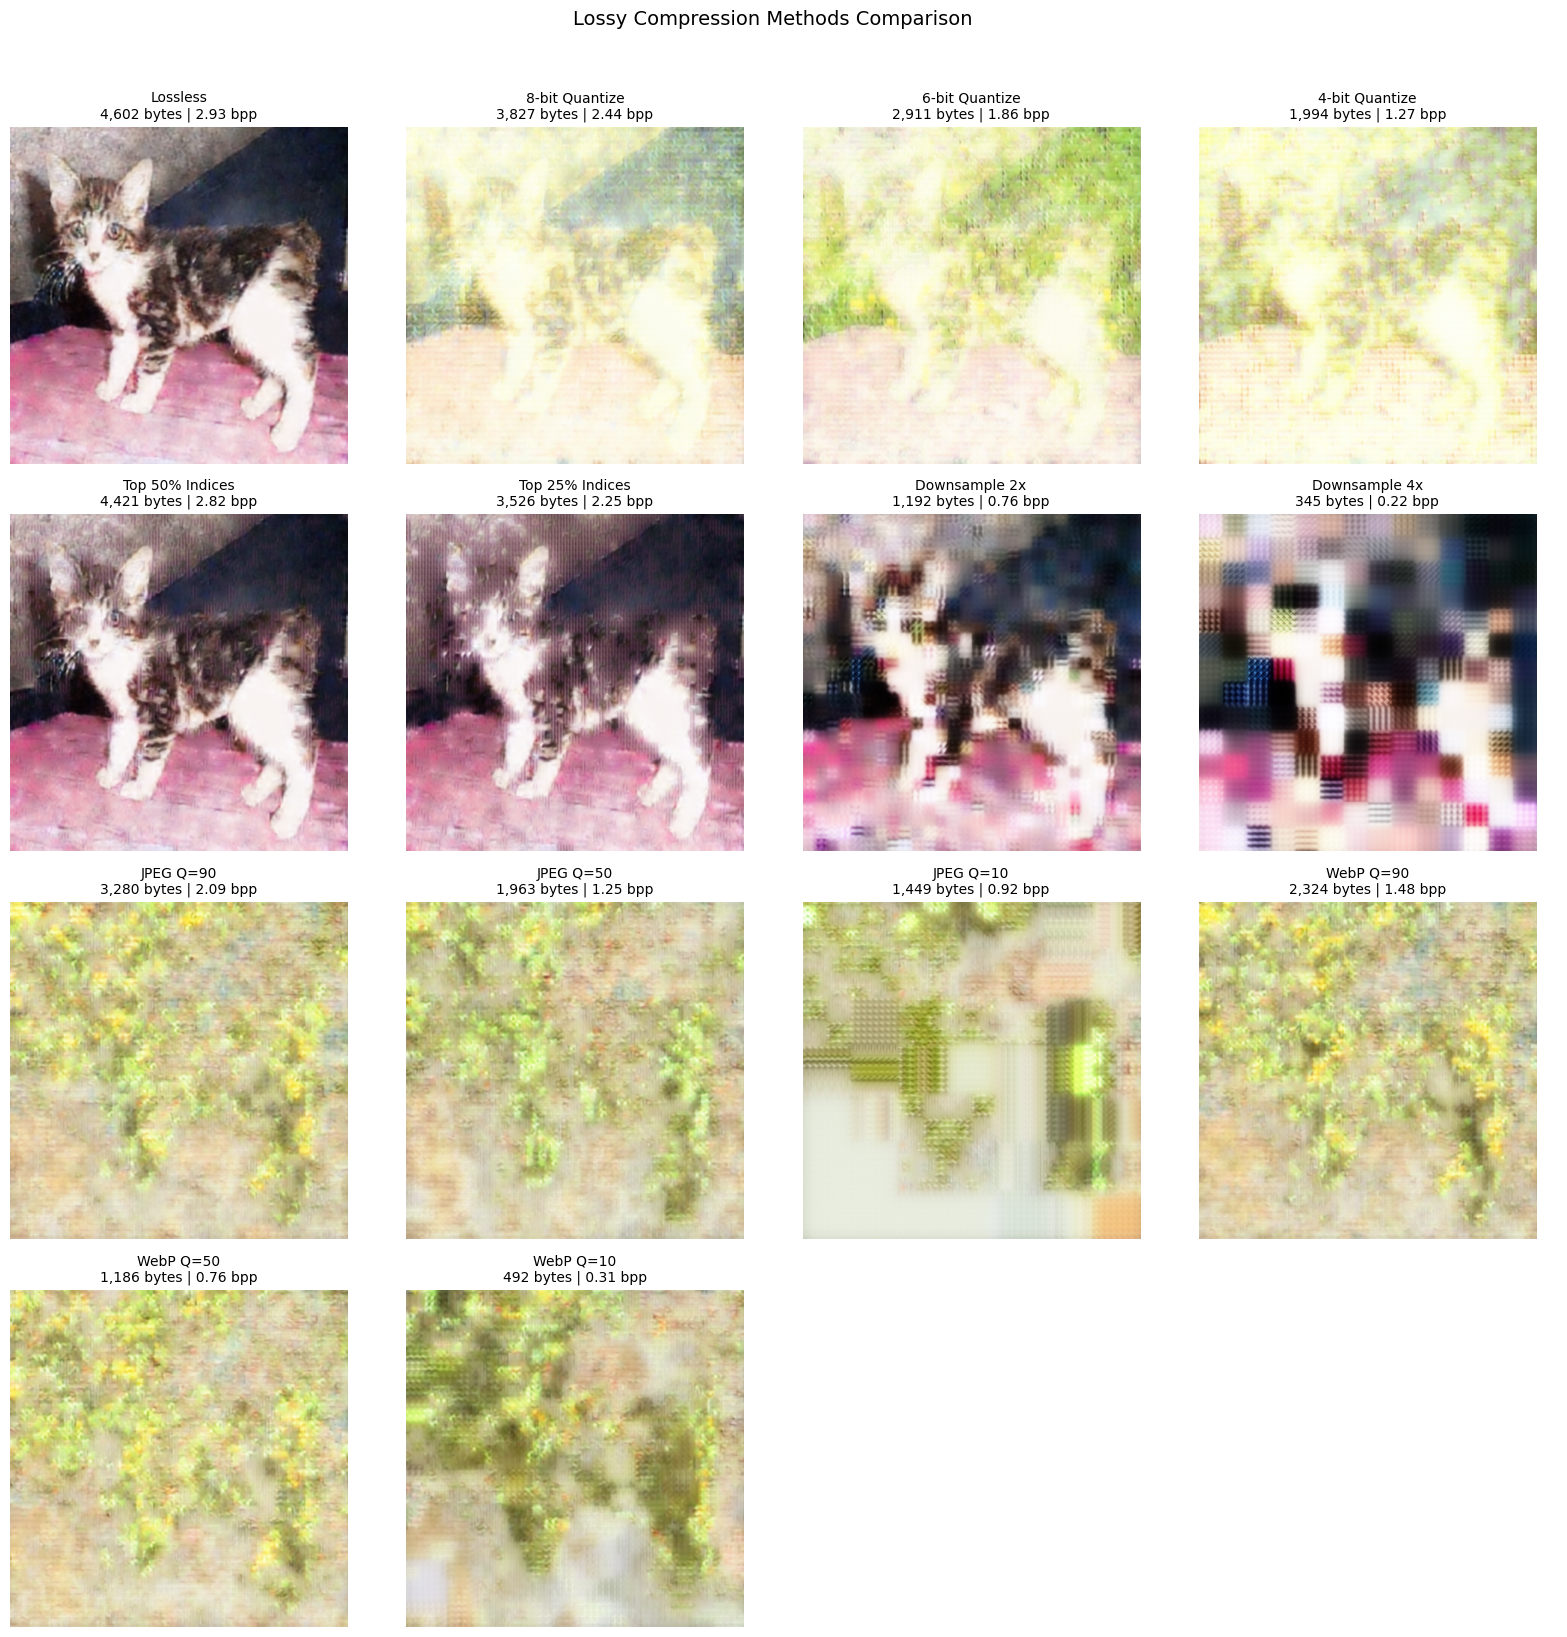

In [12]:
import matplotlib.pyplot as plt

# Calculate grid size
n_methods = len(results)
cols = 4
rows = (n_methods + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

for i, (name, data) in enumerate(results.items()):
    restored_latents = data['restored'].to(torch.int64)
    
    # Reconstruct from compressed latents
    recons = model.forward_with_latents(restored_latents)
    if isinstance(recons, tuple):
        recons = recons[0]
    
    img = recons.squeeze().cpu().detach().numpy()
    if img.shape[0] == 3:
        img = img.transpose(1, 2, 0)
    img = ((img + 1) / 2).clip(0, 1)
    
    axes[i].imshow(img)
    axes[i].set_title(f"{name}\n{data['size']:,} bytes | {data['bpp']:.2f} bpp", fontsize=10)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Lossy Compression Methods Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()